In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('datos_curados.csv')
df

,Localidad,Cultivar,Repetición,α Tocopherol,γ Tocopherol,δ Tocopherol,α+γ+δ Tocopherol,Palmitic Acid,Palmitoleic Acid,Stearic Acid,...,inicio de floración IF,Madurez fisiologica MF,Dur S-IF,Dur S-MF,Dur IF-MF,Tmx IF-MF,Tmed IF-MF,T mn IF-MF,pp IF-MF,etp IF- MF
0,Loc_1,cv_1,1,502.64,826.36,6.18,1335.18,4.26,0.20,2.04,...,2012-10-04,2012-11-26,157,211,54,29.9,23.05,17.1,214.0,222.8
1,Loc_1,cv_1,2,511.20,788.10,7.36,1306.66,4.24,0.20,1.96,...,2012-10-04,2012-11-26,157,211,54,29.9,23.05,17.1,214.0,222.8
2,Loc_1,cv_2,1,317.95,726.27,0.00,1044.22,3.96,0.17,1.89,...,2012-09-29,2012-11-25,152,210,58,28.7,21.70,15.0,214.9,232.1
3,Loc_1,cv_2,2,356.28,796.46,7.22,1159.96,4.45,0.19,2.21,...,2012-09-29,2012-11-25,152,210,58,28.7,21.70,15.0,214.9,232.1
4,Loc_1,cv_3,1,405.68,745.75,3.79,1155.22,4.17,0.17,1.95,...,2012-09-23,2012-11-17,146,202,56,28.7,21.70,15.0,185.3,225.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,Loc_4,cv_11,2,301.55,529.71,10.12,841.38,3.90,0.13,1.95,...,2012-09-18,2012-11-18,126,187,62,21.3,15.00,8.7,0.0,196.0
100,Loc_4,cv_12,1,307.06,558.40,1.97,867.43,4.01,0.20,2.06,...,2012-09-13,2012-11-15,121,184,64,21.3,14.90,8.5,0.0,196.9
101,Loc_4,cv_12,2,321.44,631.59,4.95,957.98,3.96,0.16,1.59,...,2012-09-13,2012-11-15,121,184,64,21.3,14.90,8.5,0.0,196.9
102,Loc_4,cv_13,1,284.28,621.01,7.25,912.54,3.94,0.18,2.06,...,2012-09-12,2012-11-15,120,184,65,21.3,14.90,8.4,0.0,194.3


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Localidad               104 non-null    object 
 1   Cultivar                104 non-null    object 
 2   Repetición              104 non-null    int64  
 3   α Tocopherol            104 non-null    float64
 4   γ Tocopherol            104 non-null    float64
 5   δ Tocopherol            104 non-null    float64
 6   α+γ+δ Tocopherol        104 non-null    float64
 7   Palmitic Acid           104 non-null    float64
 8   Palmitoleic Acid        104 non-null    float64
 9   Stearic Acid            104 non-null    float64
 10  Oleic Acid              104 non-null    float64
 11  Linoleic Acid           104 non-null    float64
 12  Linolenic Acid          104 non-null    float64
 13  Arachidic Acid          104 non-null    float64
 14  Ecosenoic Acid          104 non-null    fl

3) ¿El contenido de ácido linolénico se ve afectado por la temperatura durante el periodo entre
el inicio de floración y la madurez fisiológica (IF-MF)?

In [3]:
df_3 = df.copy()
df_3 = df_3[['Localidad', 'Cultivar', 'Linolenic Acid', 'Fecha de siembra S', 'inicio de floración IF', 'Madurez fisiologica MF', 'Tmx IF-MF', 'Tmed IF-MF', 'T mn IF-MF']]
df_3

,Localidad,Cultivar,Linolenic Acid,Fecha de siembra S,inicio de floración IF,Madurez fisiologica MF,Tmx IF-MF,Tmed IF-MF,T mn IF-MF
0,Loc_1,cv_1,7.11,2012-04-30,2012-10-04,2012-11-26,29.9,23.05,17.1
1,Loc_1,cv_1,7.01,2012-04-30,2012-10-04,2012-11-26,29.9,23.05,17.1
2,Loc_1,cv_2,7.92,2012-04-30,2012-09-29,2012-11-25,28.7,21.70,15.0
3,Loc_1,cv_2,7.51,2012-04-30,2012-09-29,2012-11-25,28.7,21.70,15.0
4,Loc_1,cv_3,7.04,2012-04-30,2012-09-23,2012-11-17,28.7,21.70,15.0
...,...,...,...,...,...,...,...,...,...
99,Loc_4,cv_11,8.10,2012-05-16,2012-09-18,2012-11-18,21.3,15.00,8.7
100,Loc_4,cv_12,7.94,2012-05-16,2012-09-13,2012-11-15,21.3,14.90,8.5
101,Loc_4,cv_12,8.86,2012-05-16,2012-09-13,2012-11-15,21.3,14.90,8.5
102,Loc_4,cv_13,8.15,2012-05-16,2012-09-12,2012-11-15,21.3,14.90,8.4


In [4]:
# Convierte la columna "Madurez fisiológica MF" en objetos datetime
df_3['Madurez fisiologica MF'] = pd.to_datetime(df_3['Madurez fisiologica MF'])

# Reemplaza el valor incorrecto en la columna "Madurez fisiológica MF"
df_3['Madurez fisiologica MF'] = df_3['Madurez fisiologica MF'].apply(lambda x: x.replace(year=2012) if x.year == 2026 else x)
df_3

,Localidad,Cultivar,Linolenic Acid,Fecha de siembra S,inicio de floración IF,Madurez fisiologica MF,Tmx IF-MF,Tmed IF-MF,T mn IF-MF
0,Loc_1,cv_1,7.11,2012-04-30,2012-10-04,2012-11-26,29.9,23.05,17.1
1,Loc_1,cv_1,7.01,2012-04-30,2012-10-04,2012-11-26,29.9,23.05,17.1
2,Loc_1,cv_2,7.92,2012-04-30,2012-09-29,2012-11-25,28.7,21.70,15.0
3,Loc_1,cv_2,7.51,2012-04-30,2012-09-29,2012-11-25,28.7,21.70,15.0
4,Loc_1,cv_3,7.04,2012-04-30,2012-09-23,2012-11-17,28.7,21.70,15.0
...,...,...,...,...,...,...,...,...,...
99,Loc_4,cv_11,8.10,2012-05-16,2012-09-18,2012-11-18,21.3,15.00,8.7
100,Loc_4,cv_12,7.94,2012-05-16,2012-09-13,2012-11-15,21.3,14.90,8.5
101,Loc_4,cv_12,8.86,2012-05-16,2012-09-13,2012-11-15,21.3,14.90,8.5
102,Loc_4,cv_13,8.15,2012-05-16,2012-09-12,2012-11-15,21.3,14.90,8.4


In [6]:
df_loc = df_3[df_3['Localidad'] == 'Loc_3']
df_loc

,Localidad,Cultivar,Linolenic Acid,Fecha de siembra S,inicio de floración IF,Madurez fisiologica MF,Tmx IF-MF,Tmed IF-MF,T mn IF-MF
52,Loc_3,cv_1,8.33,2012-05-08,2012-09-06,2012-10-29,25.3,16.8,12.1
53,Loc_3,cv_1,7.93,2012-05-08,2012-09-06,2012-10-29,25.3,16.8,12.1
54,Loc_3,cv_2,8.95,2012-05-08,2012-08-25,2012-10-19,21.6,16.1,11.1
55,Loc_3,cv_2,9.06,2012-05-08,2012-08-25,2012-10-19,21.6,16.1,11.1
56,Loc_3,cv_3,8.47,2012-05-08,2012-09-05,2012-10-26,25.3,16.8,12.1
57,Loc_3,cv_3,8.57,2012-05-08,2012-09-05,2012-10-26,25.3,16.8,12.1
58,Loc_3,cv_4,8.19,2012-05-08,2012-09-10,2012-10-22,25.3,16.8,12.1
59,Loc_3,cv_4,8.45,2012-05-08,2012-09-10,2012-10-22,25.3,16.8,12.1
60,Loc_3,cv_5,8.87,2012-05-08,2012-08-26,2012-10-18,21.6,16.1,11.1
61,Loc_3,cv_5,8.93,2012-05-08,2012-08-26,2012-10-18,21.6,16.1,11.1


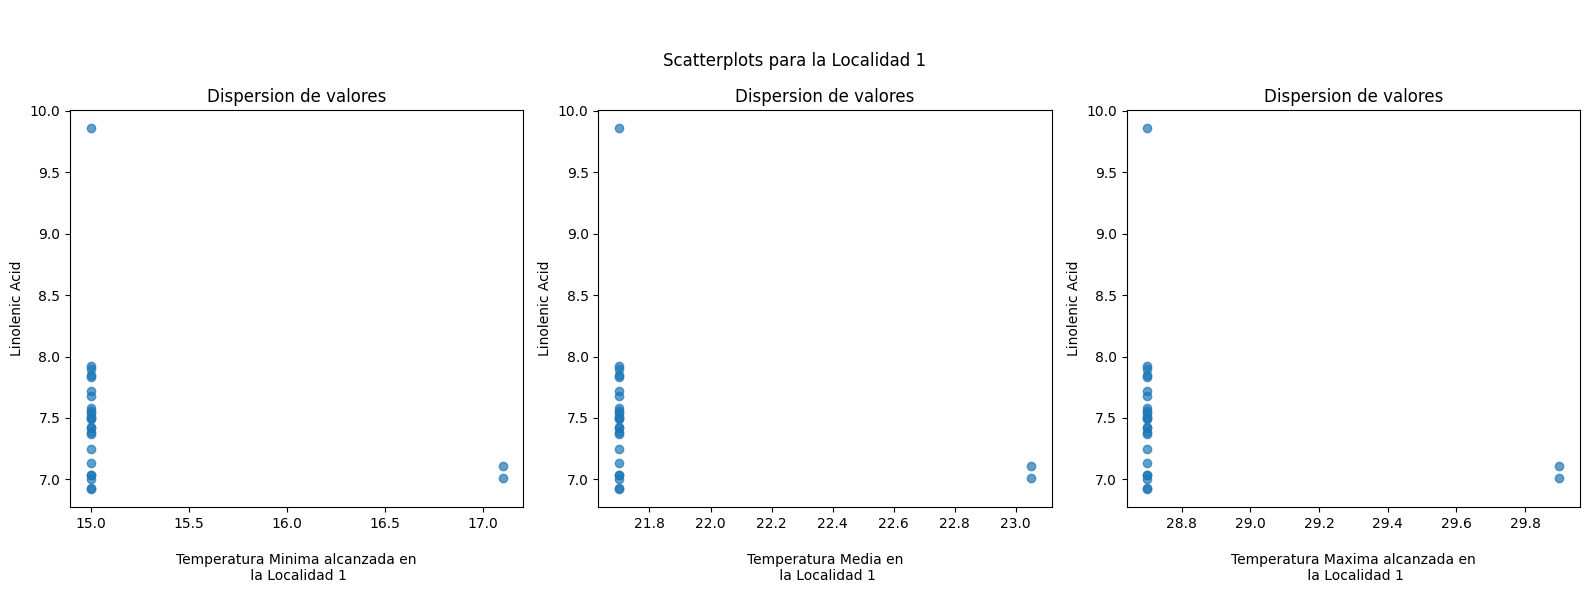

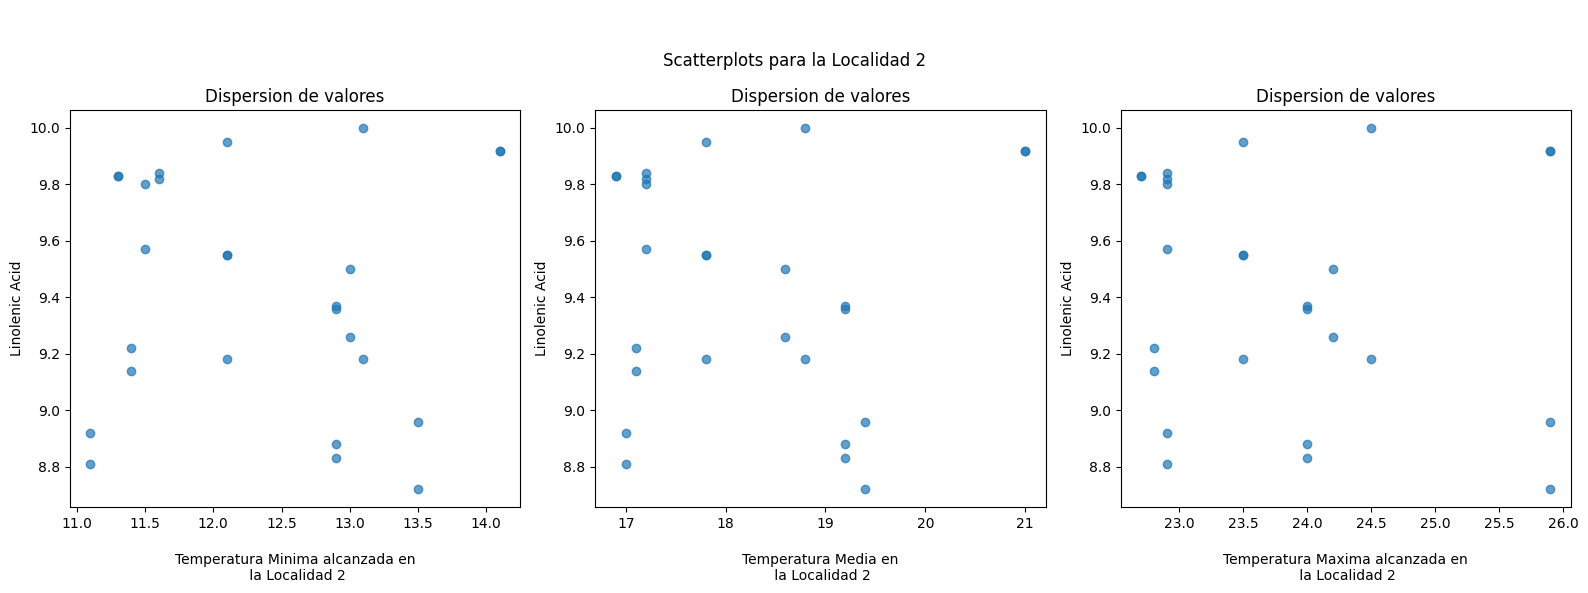

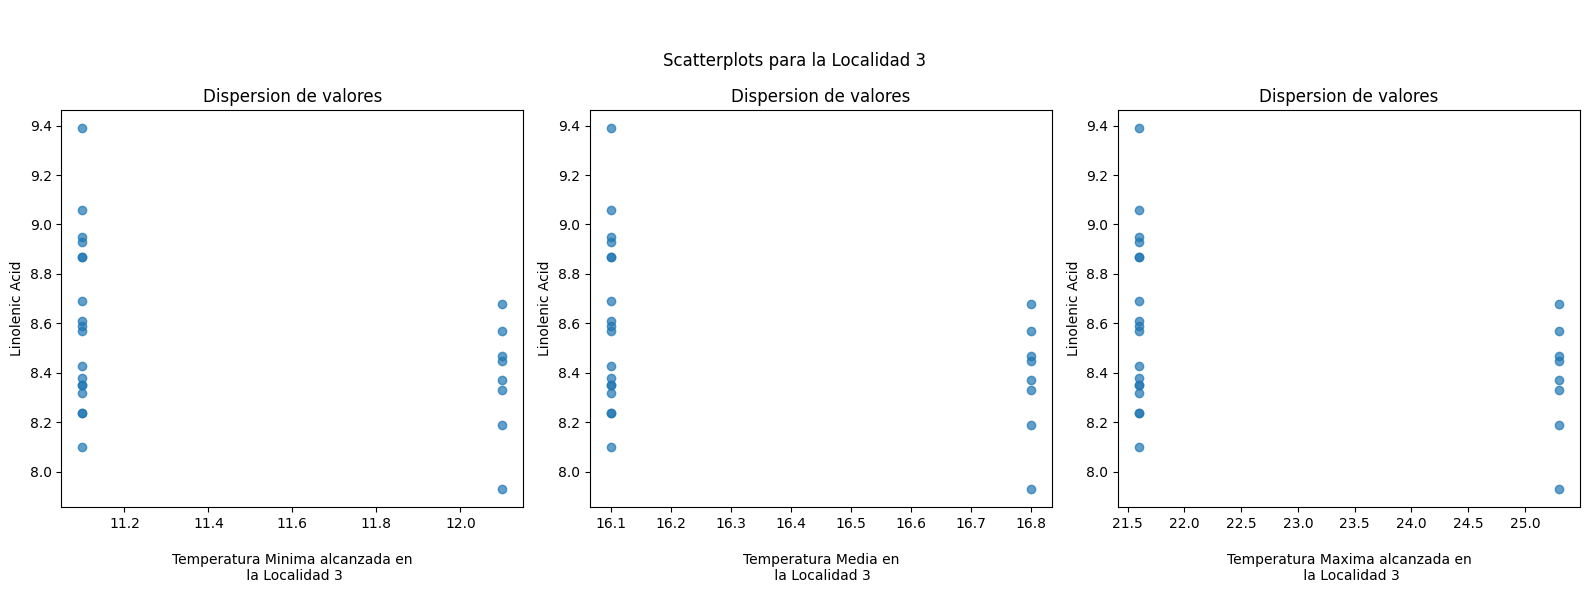

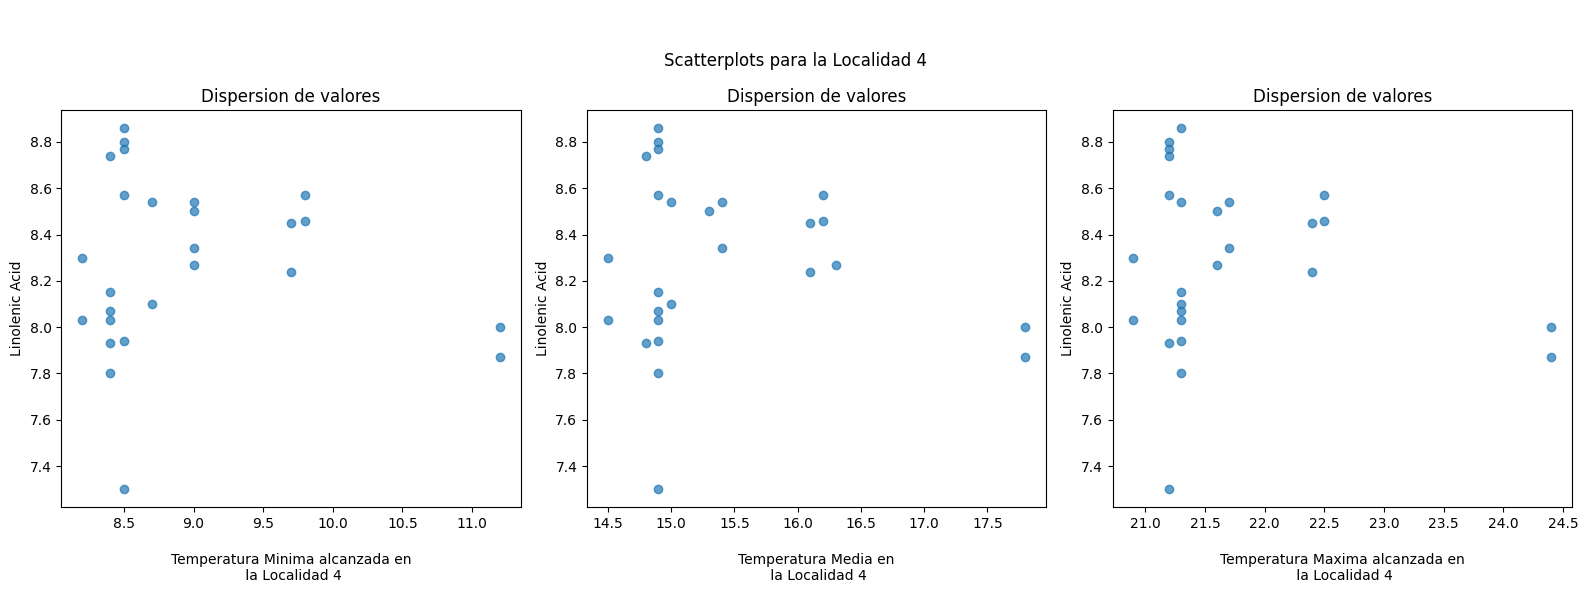

In [ ]:
tempe = ['T mn IF-MF', 'Tmed IF-MF', 'Tmx IF-MF']
tempe_name = ['Minima alcanzada en', 'Media en', 'Maxima alcanzada en']

for j, loc in enumerate(df_3['Localidad'].unique()):
    df_loc = df_3[df_3['Localidad'] == loc]

    # Crear subplots con disposición triangular invertida
    fig, axes = plt.subplots(1, 3, figsize=(16, 6))
    fig.suptitle(f'\n\nScatterplots para la Localidad {j+1}')

    for i, temp in enumerate(tempe):
        ax = axes[i]

        ax.scatter(df_loc[temp], df_loc['Linolenic Acid'], alpha=0.7)
        ax.set_xlabel(f'\nTemperatura {tempe_name[i]}\n la Localidad {j+1}')
        ax.set_ylabel('Linolenic Acid')
        ax.set_title(f'Dispersion de valores')

    plt.tight_layout()
    plt.show()


In [ ]:
df_loc.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 26 entries, 78 to 103
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Localidad               26 non-null     object        
 1   Cultivar                26 non-null     object        
 2   Linolenic Acid          26 non-null     float64       
 3   Fecha de siembra S      26 non-null     datetime64[ns]
 4   inicio de floración IF  26 non-null     datetime64[ns]
 5   Madurez fisiologica MF  26 non-null     datetime64[ns]
 6   Tmx IF-MF               26 non-null     float64       
 7   Tmed IF-MF              26 non-null     float64       
 8   T mn IF-MF              26 non-null     float64       
dtypes: datetime64[ns](3), float64(4), object(2)
memory usage: 2.0+ KB


In [ ]:
def obj_to_date(dataframe, column_name):
    # Recorrer todos los valores de la columna y convertir a datetime si es una cadena con la forma dd/mm/yyyy
    dataframe[column_name] = pd.to_datetime(dataframe[column_name], format='%Y/%m/%d')

columns = ['Fecha de siembra S', 'inicio de floración IF', 'Madurez fisiologica MF']

for col in columns:
    obj_to_date(df_3, col)

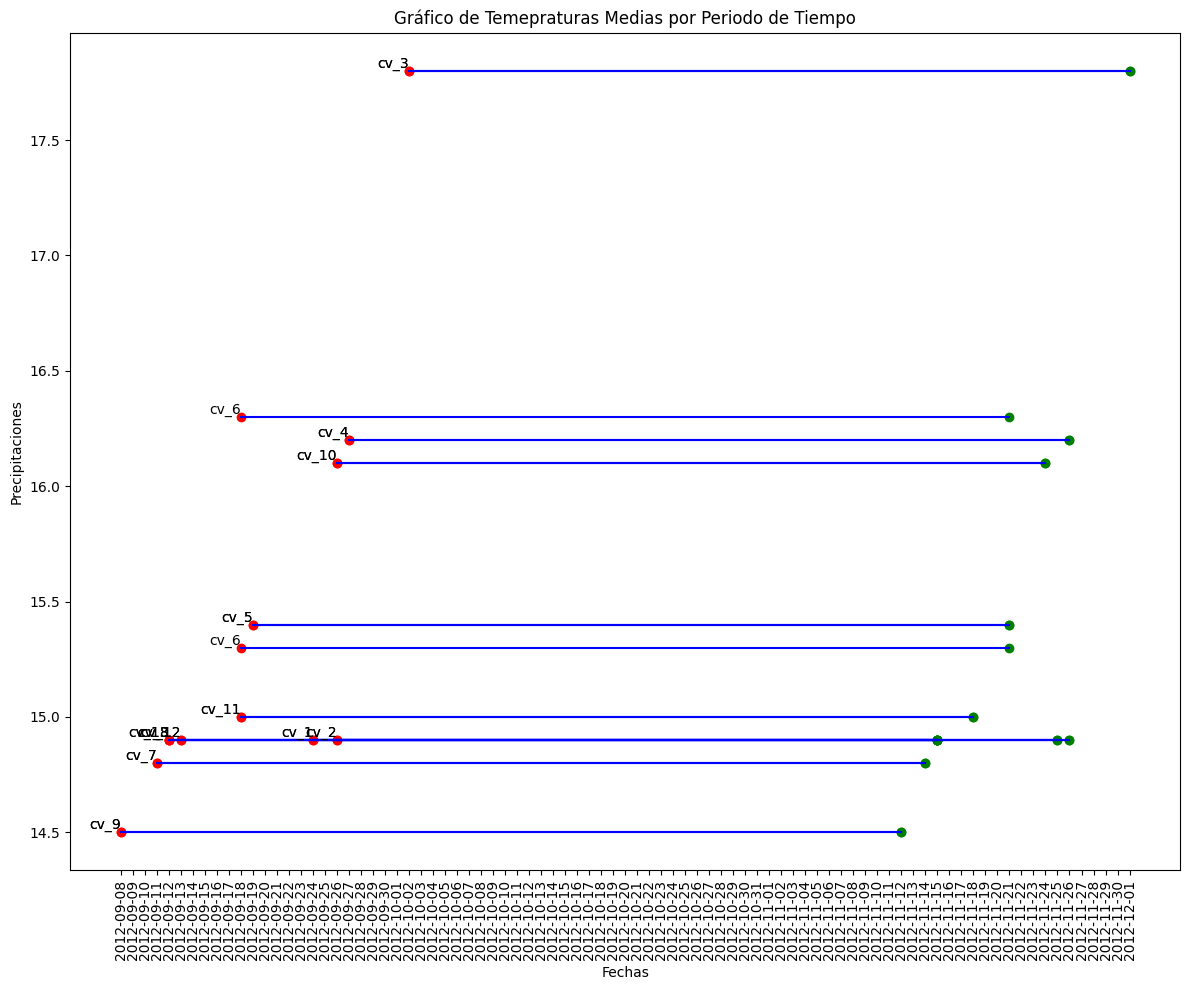

In [ ]:
plt.figure(figsize=(12, 10))

for index, row in df_loc.iterrows():
    plt.plot([row['inicio de floración IF'], row['Madurez fisiologica MF']], [row['Tmed IF-MF'], row['Tmed IF-MF']], color='blue')
    plt.scatter(row['inicio de floración IF'], row['Tmed IF-MF'], color='red', marker='o')
    plt.scatter(row['Madurez fisiologica MF'], row['Tmed IF-MF'], color='green', marker='o')

    group_label = row['Cultivar']
    plt.text(row['inicio de floración IF'], row['Tmed IF-MF'], group_label, color='black', ha='right', va='bottom')

date_range = pd.date_range(start=df_loc['inicio de floración IF'].min(), end=df_loc['Madurez fisiologica MF'].max(), freq='D')

plt.xlabel('Fechas')
plt.ylabel('Precipitaciones')
plt.title('Gráfico de Temepraturas Medias por Periodo de Tiempo')
plt.xticks(date_range, rotation=90)
plt.tight_layout()

plt.show()


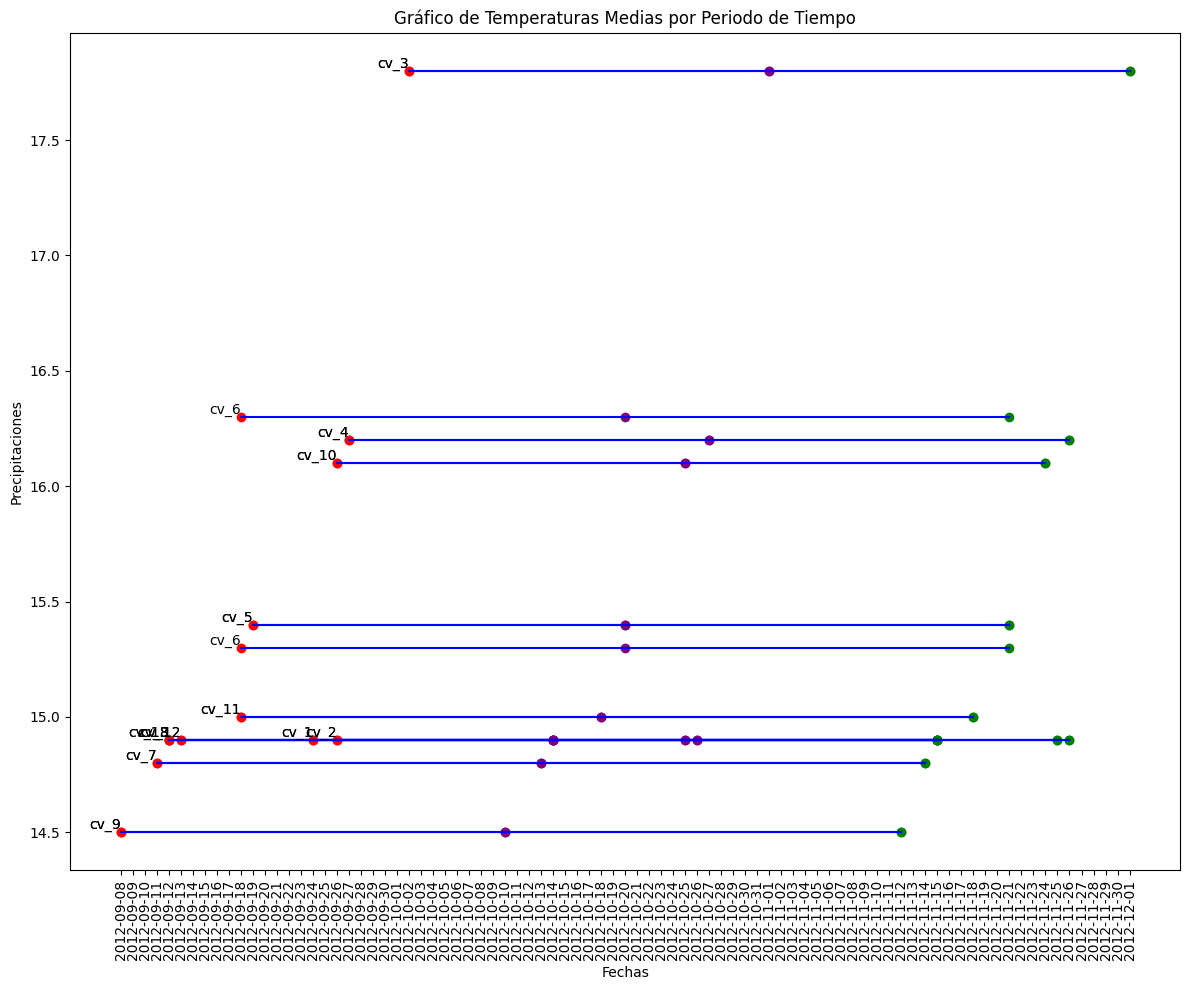

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Supongamos que ya tienes un DataFrame df_loc con los datos.

plt.figure(figsize=(12, 10))

for index, row in df_loc.iterrows():
    inicio_floracion = row['inicio de floración IF']
    madurez_fisiologica = row['Madurez fisiologica MF']
    tmed_if_mf = row['Tmed IF-MF']

    # Calcular la fecha intermedia
    fecha_intermedia = inicio_floracion + pd.DateOffset(days=(madurez_fisiologica - inicio_floracion).days // 2)

    # Dibujar una línea horizontal desde el inicio de floración hasta la madurez fisiológica
    plt.plot([inicio_floracion, madurez_fisiologica], [tmed_if_mf, tmed_if_mf], color='blue')

    # Dibujar puntos en el inicio de floración, fecha intermedia y madurez fisiológica
    plt.scatter(inicio_floracion, tmed_if_mf, color='red', marker='o')
    plt.scatter(fecha_intermedia, tmed_if_mf, color='purple', marker='o')  # Punto en la fecha intermedia
    plt.scatter(madurez_fisiologica, tmed_if_mf, color='green', marker='o')

    group_label = row['Cultivar']
    plt.text(inicio_floracion, tmed_if_mf, group_label, color='black', ha='right', va='bottom')

date_range = pd.date_range(start=df_loc['inicio de floración IF'].min(), end=df_loc['Madurez fisiologica MF'].max(), freq='D')

plt.xlabel('Fechas')
plt.ylabel('Precipitaciones')
plt.title('Gráfico de Temperaturas Medias por Periodo de Tiempo')
plt.xticks(date_range, rotation=90)
plt.tight_layout()

plt.show()


In [ ]:
from scipy.stats import t

# Calcular la correlación
correlation_if = df_loc_1['Linolenic Acid'].corr(df_loc_1['Tmed IF-MF'])

# Número de observaciones
n = len(df_loc_1)

# Calcular el estadístico de prueba t
t_stat_if = correlation_if * np.sqrt((n - 2) / (1 - correlation_if**2))

# Grados de libertad
degrees_of_freedom = n - 2

# Calcular el valor crítico de t para un nivel de significancia dado
alpha = 0.05
t_critical = t.ppf(1 - alpha/2, df=degrees_of_freedom)

# Imprimir resultados
print("Prueba de Hipótesis para la Correlación")
print("=" * 40)
print(f"Correlación en Inicio de Floración: {correlation_if:.4f}")
print(f"Estadístico de Prueba (Inicio de Floración): {t_stat_if:.4f}")
print(f"Valor Crítico de t: {t_critical:.4f}")
print("Resultado (Inicio de Floración):", "Rechazar" if abs(t_stat_if) > t_critical else "Aceptar")


Prueba de Hipótesis para la Correlación
Correlación en Inicio de Floración: -0.2258
Estadístico de Prueba (Inicio de Floración): -1.1357
Valor Crítico de t: 2.0639
Resultado (Inicio de Floración): Aceptar


<ipython-input-45-fe0052dec7e2>:10: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation_matrix = df_3[df_3['Localidad'] == loc].corr()


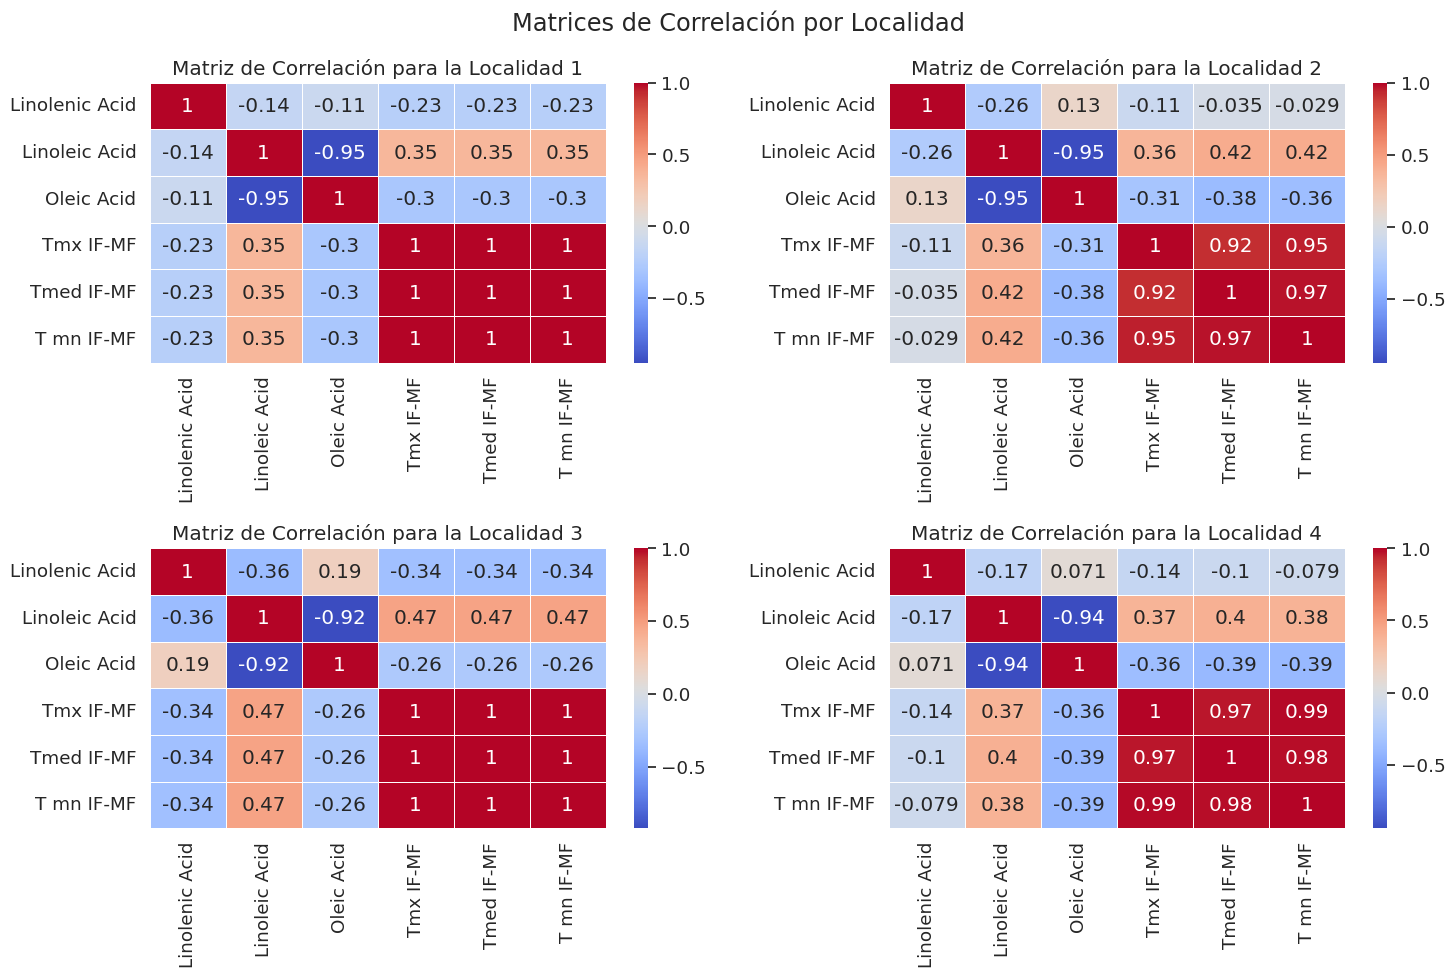

In [ ]:
# Obtener las localidades únicas en el dataframe
unique_localities = df_3['Localidad'].unique()

# Crear subplots en una cuadrícula de 2x2
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Matrices de Correlación por Localidad')

# Iterar a través de las localidades y asignar una matriz de correlación a cada subplot
for i, loc in enumerate(unique_localities):
    correlation_matrix = df_3[df_3['Localidad'] == loc].corr()

    sns.set(font_scale=1.2)
    sns.set_style("whitegrid")

    # Crear un mapa de calor (heatmap) de la matriz de correlación en el subplot correspondiente
    sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", linewidths=0.5, ax=axes[i//2, i%2])

    axes[i//2, i%2].set_title(f'Matriz de Correlación para la Localidad {i+1}')

plt.tight_layout()
plt.show()
